In [1]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, RSA, load_img_natraster, print_wise, TimeSeries, get_relevant_output_layers
from general_utils.dRSA import across_areas_dRSA
from general_utils.II import InformationImbalance, compare_similarity_metrics

In [95]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'paul'
    date: str =  "230204"#'220226to527' # '220226to527' #
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    k=1
    metrics = ["euclidean", "cosine_cnt", "cosine", "correlation"]
    model_name: str = 'vit_l_16'
    layer_name: str = 'blocks.16.mlp.fc2'
    img_size: int = 384
    pooling: str = 'mean'
    pkg: str = 'timm'

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
brain_areas = ['V1', 'V2', 'V3', 'PIT', 'CIT', 'AIT']

In [103]:
def load_and_plot_II(paths, cfg, i_mt, j_mt, idx, l, ax, ncols, color):
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{cfg.k}_{i_mt}-{j_mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{cfg.k}_{i_mt}-{j_mt}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    ax.set_title(l, fontsize=12)
    ax_right = ax.twinx()
    l_m1, = ax_right.plot(
        A2B,
        color=color,
        linestyle="--",
        linewidth=2,
    )
    
    l_m2, = ax_right.plot(
        B2A,
        color=color,
        linestyle="-",
        linewidth=2,
    )
    ax.spines["left"].set_linewidth(2.5)
    color = "tab:blue"
    ax.spines["left"].set_color(color)
    ax.tick_params(axis="y", colors=color)
    ax.yaxis.label.set_color(color)

    color = "tab:red"
    ax_right.spines["right"].set_color(color)
    ax_right.tick_params(axis="y", colors=color)
    ax_right.yaxis.label.set_color(color)
    
    ax_right.spines["right"].set_linewidth(2.5)
    ax_right.set_ylim([.4, 1.05])
    if idx % ncols != ncols - 1:
        ax_right.set_yticks([.4, .6, .8, 1.0])
        ax_right.set_yticklabels([])
        ax_right.set_ylabel("")
    else:
        ax_right.tick_params(axis='both', labelsize=15)
    return l_m1, l_m2, A2B


def plot_metrics_II(paths, layers, cfg, ylim = None, save=False, colors=["tab:blue", "tab:cyan", "mediumseagreen", "tab:green"]):
    n_layers = len(layers)
    ncols = 4
    nrows = int(np.ceil(n_layers / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows),
        sharex=True, sharey=True
    )
    axes = axes.flatten()
    

    for idx, (ax, l) in enumerate(zip(axes, layers)):
        handles = []
        labels = []
        counter = 0
        for i_mt in [cfg.RDM_metric1,cfg.RDM_metric2]:  
            for j_mt in [cfg.RDM_metric1,cfg.RDM_metric2]:  
                l_m_A2B, l_m_B2A, ii = load_and_plot_II(paths, cfg, i_mt, j_mt, idx, l, ax, ncols, colors[counter]) 
                counter +=1
                handles.append(l_m_A2B)
                handles.append(l_m_B2A)
                labels.append(f"neural->model {i_mt}-{j_mt} ")
                labels.append(f"model->neural {i_mt}-{j_mt}")

    # remove unused axes
    for ax in axes[len(layers):]:
        ax.axis("off")

    fig.supxlabel("Time from image onset (ms)", fontsize=20)
    fig.supylabel("RSA Similarity", fontsize=20, color='tab:blue')
    fig.suptitle(f"Brain area: {cfg.brain_area}", fontsize=27)
    fig.tight_layout()

    fig.legend(handles, labels,fontsize=12, bbox_to_anchor=(0.98, 0.90))
    # make space on the right for the legend
    fig.tight_layout(rect=[0.03, 0, 0.80, .97])
    fig.text(
        0.85, 0.5,                  # x, y in figure coordinates
        "Information Imbalance",
        va="center",
        ha="right",
        rotation=-90,
        fontsize=20,
        color='tab:red'
    )
    # ax.set_xticks(xtickspos)           # positions of ticks
    # ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
    if ylim is not None:
        for ax in axes[:n_layers]:
            ax.set_ylim(ylim[0], ylim[1])
    xtickspos = range(0, len(ii)+1, 10)       
    for ax in axes[:n_layers]:  # only the used axes
        ax.set_xticks(xtickspos)
        ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
        ax.tick_params(axis='both', labelsize=15)
        # ax_right = ax.twinx()
        # ax_right.tick_params(axis='right', labelsize=15)
    if save==True:
        return fig, axes
    else:
        plt.show()


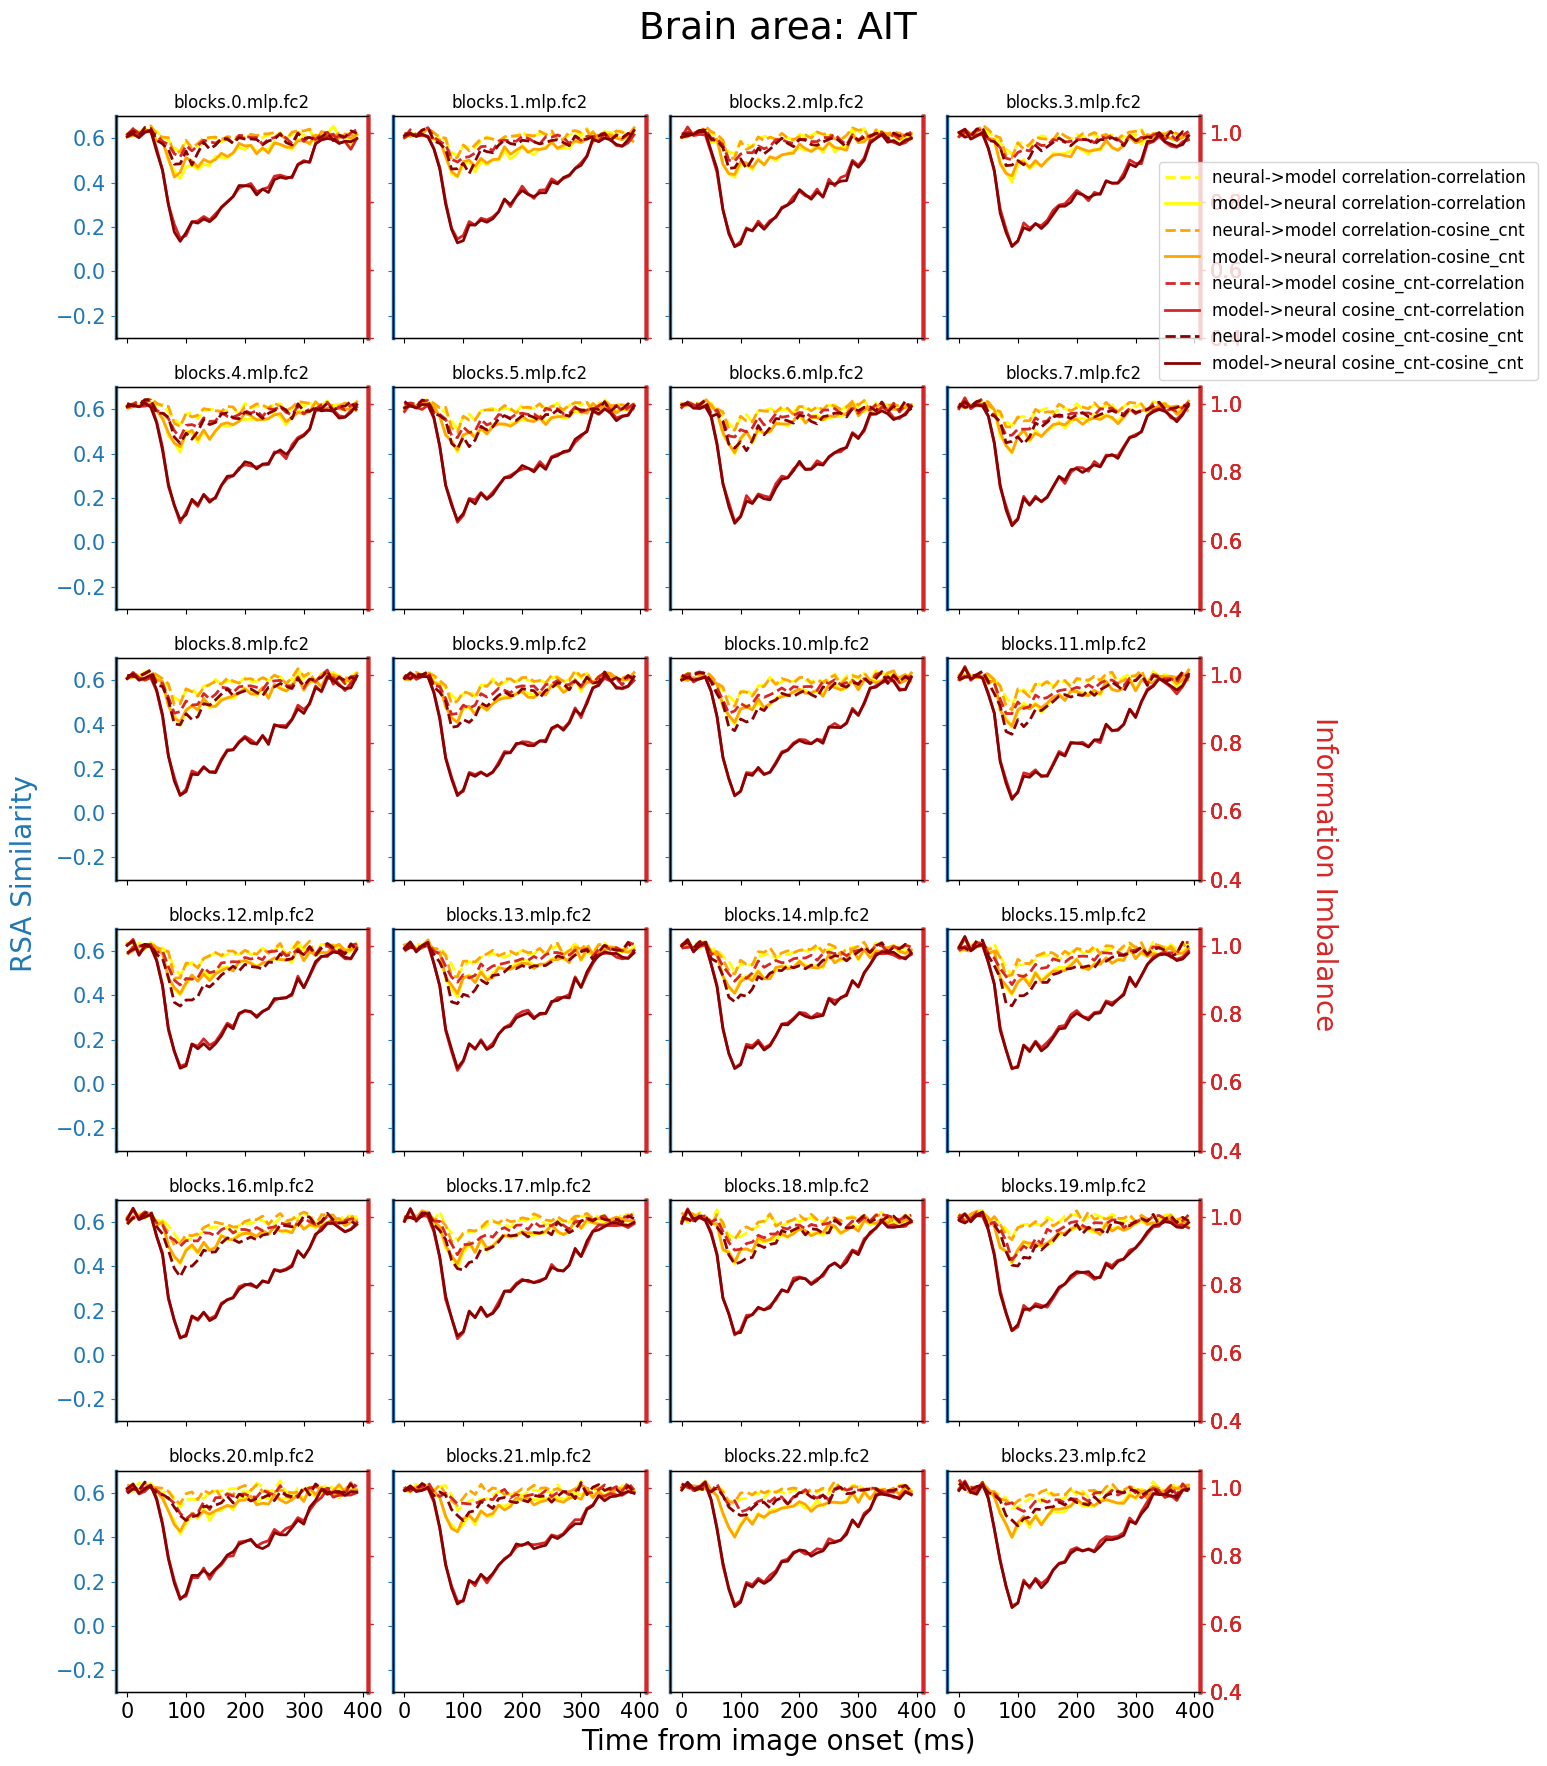

In [122]:
plot_metrics_II(paths, layers, cfg, ylim=[-.3, .7], colors= ["darkred", "tab:red", "orange", "yellow"][::-1])

In [8]:
target_metric = "euclidean"; comparing_metric = "correlation"; 


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{comparing_metric}-{target_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
A2B = np.load(save_name_A2B)["arr_0"]
B2A = np.load(save_name_B2A)["arr_0"]

In [28]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyArrowPatch
import numpy as np
from matplotlib.patches import FancyArrowPatch
import numpy as np

def draw_directed_edge(ax, p0, p1, alpha,
                       color="k", lw=1, arrow_scale=15):
    """
    Draw a straight edge p0 -> p1 with:
    - full line always present
    - arrowhead positioned at alpha along the line
    """
    p0 = np.asarray(p0)
    p1 = np.asarray(p1)

    # 1) full supporting line
    ax.plot(
        [p0[0], p1[0]],
        [p0[1], p1[1]],
        color=color,
        linewidth=lw,
        zorder=1,
    )

    # 2) arrowhead placed along the line
    direction = p1 - p0
    direction /= np.linalg.norm(direction)

    point = p0 + alpha * (p1 - p0)

    arrow = FancyArrowPatch(
        point - 1e-3 * direction,   # minimal shaft → always visible
        point,
        arrowstyle='-|>',
        mutation_scale=arrow_scale,
        linewidth=lw,
        color=color,
        zorder=2
    )
    ax.add_patch(arrow)


In [96]:
for monkey_name, date in zip(["paul", "baby1", "red", "three0"],["230204", "220226to527", "220227", "250313"]):
    print(f"\n\n{monkey_name}" )
    for i, target_metric in enumerate(cfg.metrics):
        for j, comparing_metric in enumerate(cfg.metrics):
            if i != j:
                save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
                save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{comparing_metric}-{target_metric}_{monkey_name}_{date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
                A2B = np.max(np.load(save_name_A2B)["arr_0"])
                B2A = np.max(np.load(save_name_B2A)["arr_0"])
                print(target_metric, comparing_metric, f"\nA2B {A2B}", f"B2A {B2A}\n")
                
                



paul
euclidean cosine_cnt 
A2B 0.0018475708144568815 B2A 0.04388716664346503

euclidean cosine 
A2B 0.0034888584370634523 B2A 0.17966065475391674

euclidean correlation 
A2B 0.005578415303498583 B2A 0.27658473330041783

cosine_cnt euclidean 
A2B 0.04388716664346503 B2A 0.0018475708144568815

cosine_cnt cosine 
A2B 0.060337416038904426 B2A 0.053858599657617925

cosine_cnt correlation 
A2B 0.004309711037022456 B2A 0.16803853862764992

cosine euclidean 
A2B 0.17966065475391674 B2A 0.0034888584370634523

cosine cosine_cnt 
A2B 0.053858599657617925 B2A 0.060337416038904426

cosine correlation 
A2B 0.0017893187795112978 B2A 0.10228337015582263

correlation euclidean 
A2B 0.27658473330041783 B2A 0.005578415303498583

correlation cosine_cnt 
A2B 0.16803853862764992 B2A 0.004309711037022456

correlation cosine 
A2B 0.10228337015582263 B2A 0.0017893187795112978



baby1
euclidean cosine_cnt 
A2B 0.009953975664103101 B2A 0.1540338068599078

euclidean cosine 
A2B 0.01213564849840544 B2A 0.339221

In [97]:
G = nx.DiGraph()

for i, target_metric in enumerate(cfg.metrics):
    for j, comparing_metric in enumerate(cfg.metrics):
        if i != j:
            save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
            A2B = (1 - np.max(np.load(save_name_A2B)["arr_0"]))**2
            print(A2B)
            G.add_edge(target_metric, comparing_metric, weight=A2B)
pos = nx.circular_layout(G)
pos = {node: 0.5 * coord for node, coord in pos.items()}

0.9963082718890007
0.9930344552590669
0.9888742881103012
0.9141517501090612
0.882965771696443
0.9913991515351777
0.6729566413587725
0.8951835494418436
0.9964245641026722
0.5233296480940275
0.6921598732088163
0.8058951474987877


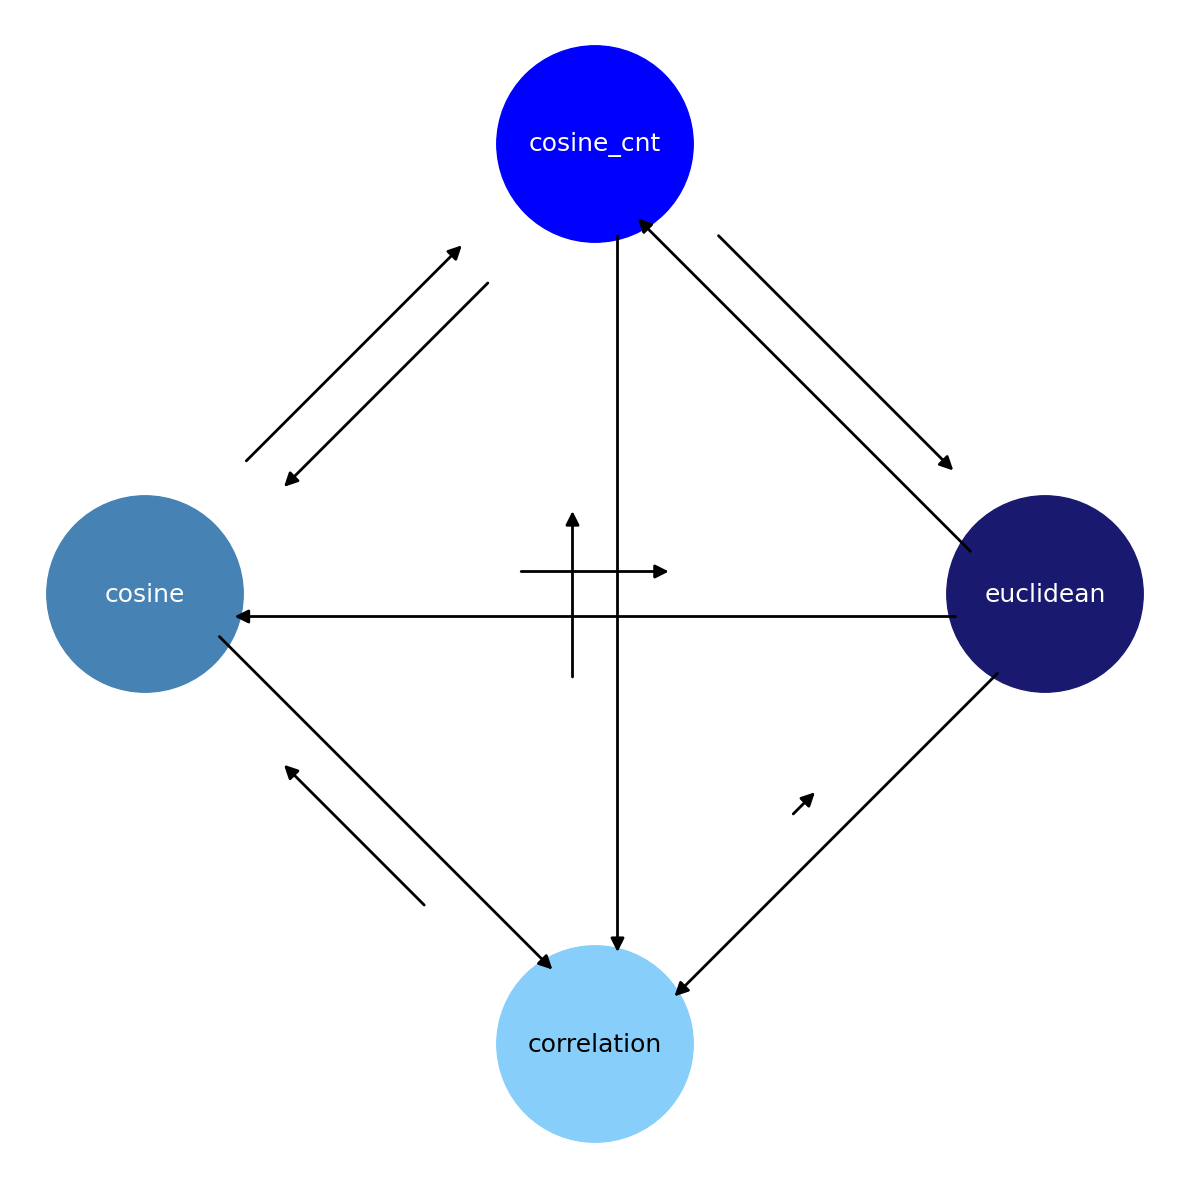

In [114]:
from matplotlib.patches import FancyArrowPatch
from general_utils.plots import truncate_colormap
import matplotlib.colors as mcolors

def draw_parallel_bidirectional_edge(ax, p0, p1, w01, w10,
                                     color="k", lw=2,
                                     arrow_scale=20,
                                     separation=0.05,
                                     node_radius=0.15,  # Increased to match larger nodes
                                     margin=0.02):

    p0 = np.asarray(p0)
    p1 = np.asarray(p1)

    vec = p1 - p0
    total_length = np.linalg.norm(vec)
    direction = vec / total_length
    mid = (p0 + p1) / 2

    # usable length between circle borders
    usable_length = total_length - 2 * node_radius - 2 * margin
    usable_length = max(usable_length, 0)

    # perpendicular direction
    perp = np.array([-direction[1], direction[0]])

    # shift midpoint to be between circle borders
    center_segment_start = p0 + direction * (node_radius + margin)
    center_segment_end   = p1 - direction * (node_radius + margin)
    mid = (center_segment_start + center_segment_end) / 2

    # ---- A → B ----
    if w01 > 0:
        alpha = np.clip(w01, 0.01, 1.0)
        half_len = alpha * usable_length / 2

        start = mid - direction * half_len
        end   = mid + direction * half_len

        offset = separation * perp

        arrow = FancyArrowPatch(
            start + offset,
            end + offset,
            arrowstyle='-|>',
            mutation_scale=arrow_scale,
            linewidth=lw,
            color=color,
            zorder=2
        )
        ax.add_patch(arrow)

    # ---- B → A ----
    if w10 > 0:
        alpha = np.clip(w10, 0.01, 1.0)
        half_len = alpha * usable_length / 2

        start = mid + direction * half_len
        end   = mid - direction * half_len

        offset = -separation * perp

        arrow = FancyArrowPatch(
            start + offset,
            end + offset,
            arrowstyle='-|>',
            mutation_scale=arrow_scale,
            linewidth=lw,
            color=color,
            zorder=2
        )
        ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(12,12))
pos = nx.circular_layout(G)

# Larger nodes
# colors = [truncate_colormap(plt.cm.Blues, maxval=.9)(i / (len(cfg.metrics) - 1)) for i in range(len(cfg.metrics))]  # from light to dark
colors= ["midnightblue","blue","steelblue", "lightskyblue",]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=20000)
# Compute label colors based on brightness
import matplotlib.colors as mcolors

def get_label_color(color):
    """
    Returns 'white' if color is dark, 'black' if light.
    Accepts: color name (str), RGB tuple, or RGBA tuple
    """
    try:
        # convert string color names to RGB
        rgb = mcolors.to_rgb(color)
    except ValueError:
        # assume it's already a tuple/list
        rgb = color[:3]  # take first 3 values if RGBA

    r, g, b = rgb
    lum = 0.299*r + 0.587*g + 0.114*b
    return 'white' if lum < 0.5 else 'black'

label_colors = {node: get_label_color(color) for node, color in zip(G.nodes(), colors)}

# draw nodes
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=2000)

# draw labels individually
for node, (x, y) in pos.items():
    plt.text(
        x, y, str(node),
        color=label_colors[node],
        fontsize=18,
        ha='center',
        va='center'
    )

drawn_pairs = set()

for u, v in G.edges():
    pair = tuple(sorted([u, v]))
    if pair in drawn_pairs:
        continue
    drawn_pairs.add(pair)

    w_uv = G[u][v]["weight"] if G.has_edge(u, v) else 0
    w_vu = G[v][u]["weight"] if G.has_edge(v, u) else 0

    draw_parallel_bidirectional_edge(
        ax, pos[u], pos[v], w_uv**4, w_vu**4,
        node_radius=0.15  # Pass the increased radius
    )

ax.set_aspect('equal')
ax.axis('off')
# Add margins to prevent clipping
ax.margins(0.15)
plt.tight_layout()
plt.show()